# Выполнил Тюрин Егор БПМ 242
## Задача
1. (1 балл) Выбрать и загрузить датасет с помощью библиотеки Pandas. Датасет должен относиться к задаче регрессии, содержать непрерывные данные. 

 С помощью библиотеки Pandas произвести предварительный анализ датасета на наличие пропусков и искажений. Произвести исправление данных при необходимости. Произвести стандартизацию данных. 


 2. (4 балла) Разделить данные на обучающий и проверочный наборы. Решить задачу регрессии, используя библиотеку sklearn несколькими методами (линейная LinearRegression, добавление квадратичных и кубических компонентов с помощью PolynomialFeatures, Lasso, Ridge Regression). 

Использовать RANSACRegressor. Посчитать метрики задачи регрессии для обучающих и проверочных данных (MSE, MAE,R2), построить Residuals plot. Сделать выводы. 

 3. (3 балла) Применить методы KMeans и DBSCAN для кластеризации данных. 

Cделать выводы - проанализировать, как полученные кластеры связаны с диапазонами значений исходных переменных и целевой переменной. Построить scatter plot полученных кластеров (для выбранных двух параметров), раскрасить точки на основе значений выбранных параметров.

Оценить качество полученной кластеризации с помощью силуэтного графика и правила локтя.

## Решение 1 пункта


In [137]:
# Импорт библиотек для выполнения ДЗ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

In [138]:
# Выгрузка датасета с git
url = "https://raw.githubusercontent.com/MovetOn31/SRS_2_year_of_bachelor/main/winequality-red.csv"
df = pd.read_csv(url, sep = ',')
df.info()
df.shape
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Количество строк: 1599
Количество столбцов: 12


Как видно, нет столюцов с типом string есть только float, так что OHE не пригодится(quality – целевая, так что не надо ее трогать )

In [139]:
df.info()

tr = df.isna()
print(tr.sum())

t_dup = df.duplicated().sum()
print(t_dup)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides             

видно, что из 1599 строк имеем 240 дубликатов, возможно это связано с качеством данных или точностью измерения по переменным. 

In [140]:
df = df.drop_duplicates().reset_index(drop=True)

print("Размер датасета после удаления дубликатов:", df.shape)

Размер датасета после удаления дубликатов: (1359, 12)


Очистили от дубликатов.

In [141]:
y = df["quality"]
X = df.drop("quality", axis=1)

X_cols = X.columns

scal = StandardScaler()
X_stand = scal.fit_transform(X)
X = pd.DataFrame(X_stand, columns=X_cols)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
dtypes: float64(11)
memory usage: 116.9 KB


После предварительной обработки(очистка дубликатов) была выделена целевая переменная quality, а остальные столбцы были использованы как признаки, которые надо было стандартизировать

## Решение 2 пункта

In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.4, 
    random_state=67
)

Разбиение на тест и траейн. 

In [143]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "Ridge": Ridge(alpha=1.0),
    "RANSAC": RANSACRegressor(
        estimator=LinearRegression(),
        random_state=67),
    "PolynomialFeatures_degree_2": make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        Ridge(alpha=10.0)
    ),
    "PolynomialFeatures_degree_3": make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),
        Ridge(alpha=100.0)
    )
}

Подгружаем модели

In [144]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results[name] = {
        "Train_MSE": mean_squared_error(y_train, y_train_pred),
        "Train_MAE": mean_absolute_error(y_train, y_train_pred),
        "Train_R2": r2_score(y_train, y_train_pred),
        "Test_MSE": mean_squared_error(y_test, y_test_pred),
        "Test_MAE": mean_absolute_error(y_test, y_test_pred),
        "Test_R2": r2_score(y_test, y_test_pred),
        "y_test": y_test,
        "y_test_pred": y_test_pred
    }

results_df = pd.DataFrame({
    name: {
        k: v
        for k, v in res.items()
        if k not in ["y_test", "y_test_pred"]
    }
    for name, res in results.items()
}).T

results_df.round(4)

,Train_MSE,Train_MAE,Train_R2,Test_MSE,Test_MAE,Test_R2
LinearRegression,0.4723,0.5278,0.3678,0.3867,0.4901,0.3263
Lasso,0.4736,0.5269,0.3660,0.3770,0.4859,0.3431
Ridge,0.4723,0.5278,0.3678,0.3865,0.4900,0.3267
RANSAC,0.8552,0.6642,-0.1447,0.9277,0.6779,-0.6164
PolynomialFeatures_degree_2,0.3932,0.4880,0.4737,0.5260,0.5491,0.0836
PolynomialFeatures_degree_3,0.3012,0.4247,0.5968,1.0681,0.6022,-0.8609


По результатам обучения лучшее качество на проверочной выборке показала модель Lasso

Линейка, Ridge и полиномиальные модели показали почти одинаковые результаты. Это значит, что добавление полиномиальных признаков после регуляризации не дало заметного улучшения.

RANSACRegressor показал отрицательный Test_R2. Это означает, что для данного датасета он оказался хуже обычной линейной модели.(а не прогблемы)

В целом модели объясняют около 33-34% разброса целевой переменной quality. Это умеренный результат, что нормально для данного датасета, так как quality принимает небольшое число целочисленных значений.

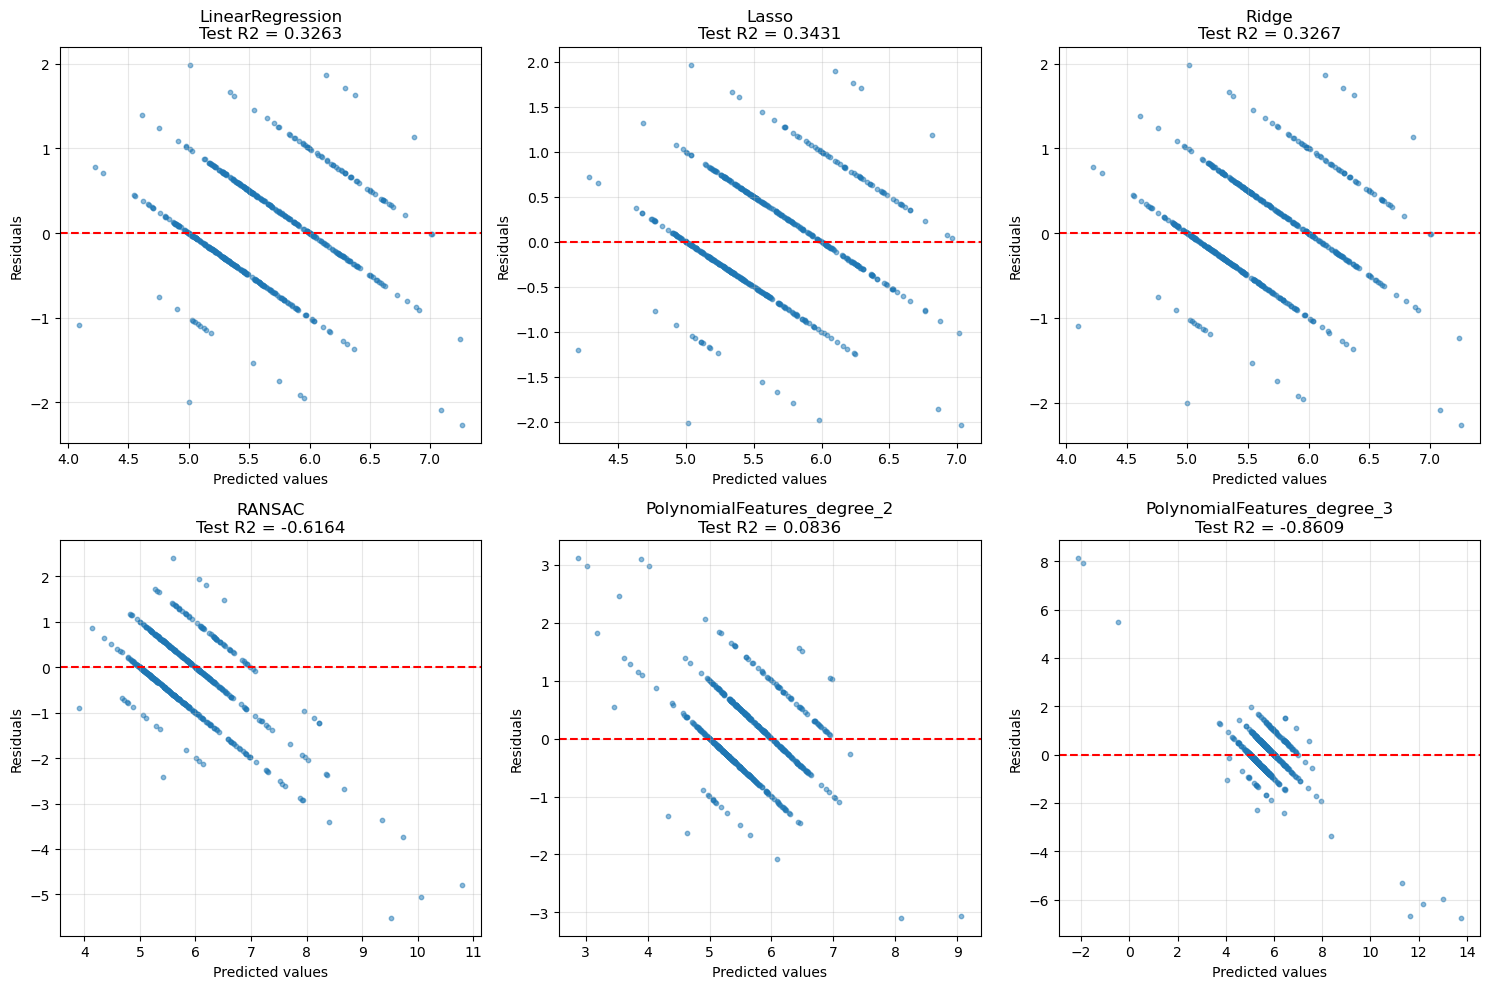

In [145]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, res) in enumerate(results.items()):
    residuals = res["y_test"] - res["y_test_pred"]
    axes[idx].scatter(
        res["y_test_pred"], 
        residuals, 
        alpha=0.5, 
        s=10
    )

    axes[idx].axhline(
        y=0, 
        color="r", 
        linestyle="--"
    )

    axes[idx].set_xlabel("Predicted values")
    axes[idx].set_ylabel("Residuals")
    axes[idx].set_title(f"{name}\nTest R2 = {res['Test_R2']:.4f}")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

По residuals plot видно, что у LinearRegression, Lasso, Ridge и полиномиальных моделей остатки в основном расположены вокруг нуля. Это означает, что модели не имеют сильного постоянного смещения.

При этом точки образуют несколько диагональных линий. Это связано с тем, что целевая переменная quality принимает только целочисленные значения, а модели предсказывают непрерывные значения. В принципе, все логично.

Lasso показала лучший результат среди моделей. Ее график остатков похож на LinearRegression и Ridge, но метрики немного лучше. Так что да...

У RANSAC остатки имеют больший разброс, а Test_R2 отрицательный. Это подтверждает, что RANSAC хуже подошел для данного датасета.

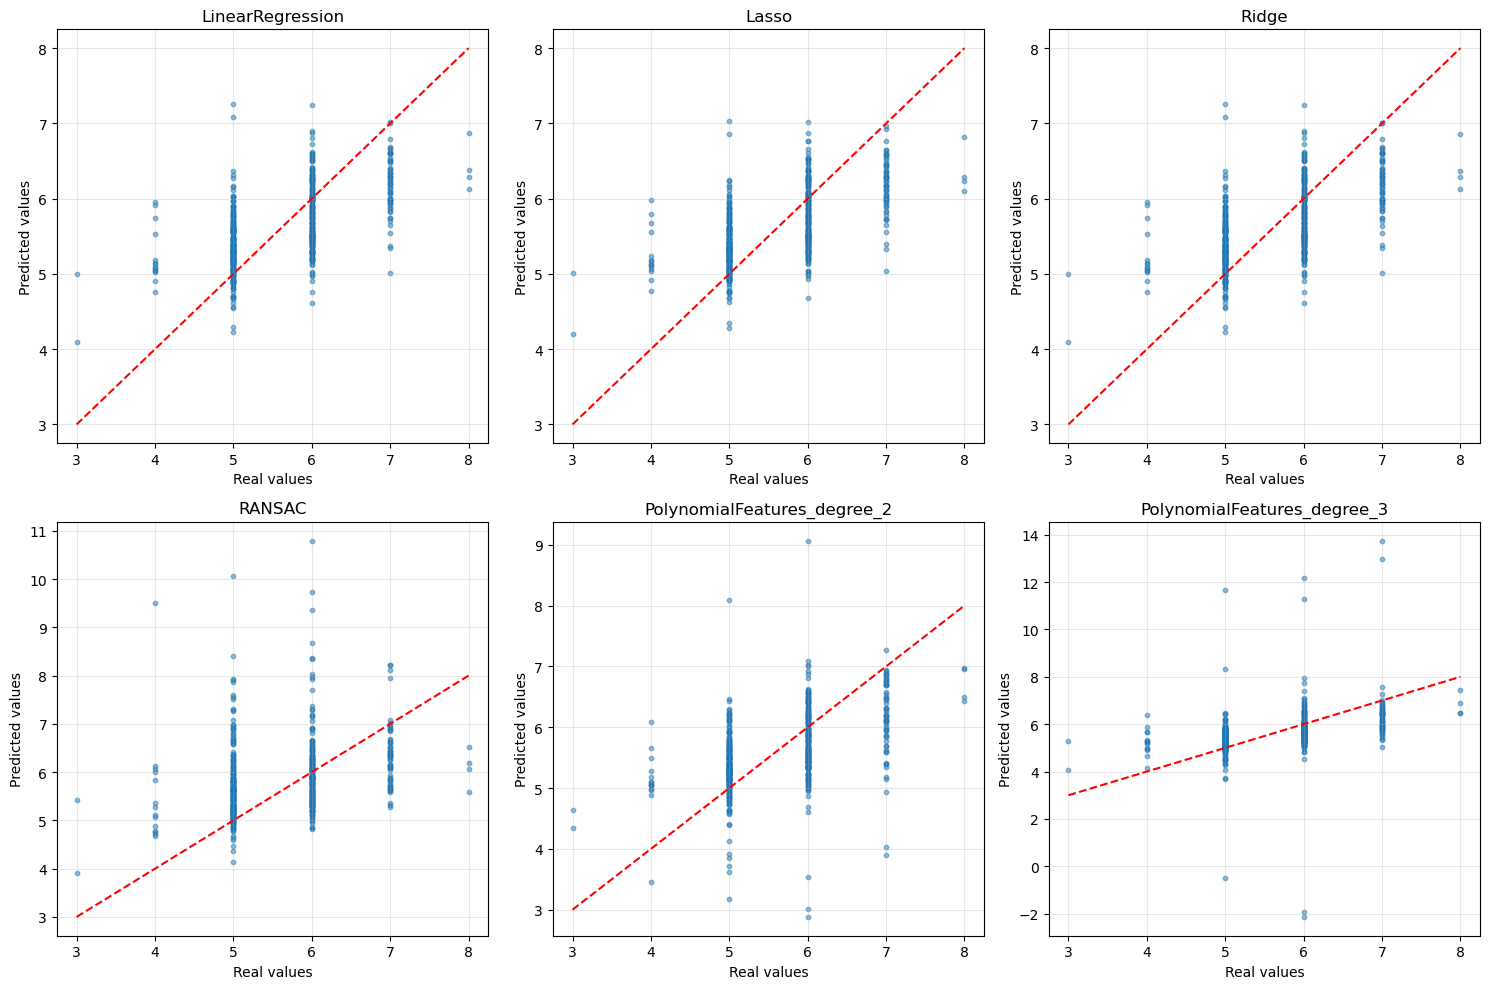

In [146]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, res) in enumerate(results.items()):
    axes[idx].scatter(
        res["y_test"], 
        res["y_test_pred"], 
        alpha=0.5, 
        s=10
    )

    axes[idx].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="r",
        linestyle="--"
    )

    axes[idx].set_xlabel("Real values")
    axes[idx].set_ylabel("Predicted values")
    axes[idx].set_title(name)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Это дополнительная часть, которую я седалл для себя. На графиках показано сравнение реальных и предсказанных значений quality.

У LinearRegression, Lasso и Ridge предсказания расположены относительно близко к диагональной линии. Это означает, что модели частично улавливают зависимость между признаками и качеством вина. Однако видно, что модели чаще всего предсказывают значения около 5-6. Это связано с тем, что таких оценок в датасете больше всего.

RANSAC дает более широкий разброс предсказаний и хуже попадает в реальные значения. Это согласуется с отрицательным значением Test_R2. Как и с графиком выше.

Полиномиальная модель степени 2 работает примерно на уровне линейных моделей. Полиномиальная модель степени 3 нестабильна: на графике видны слишком большие предсказанные значения, поэтому эта модель переобучается и плохо подходит для данного датасета. Мне честно, лень переделывать) 

В целом лучше всего выглядят Lasso, Ridge и LinearRegression, при этом по метрикам лучший результат показала Lasso.

## Выполение задачи 3

In [147]:
df_cluster = df.copy()
X_cluster = X.copy()

Скопирую на всякий

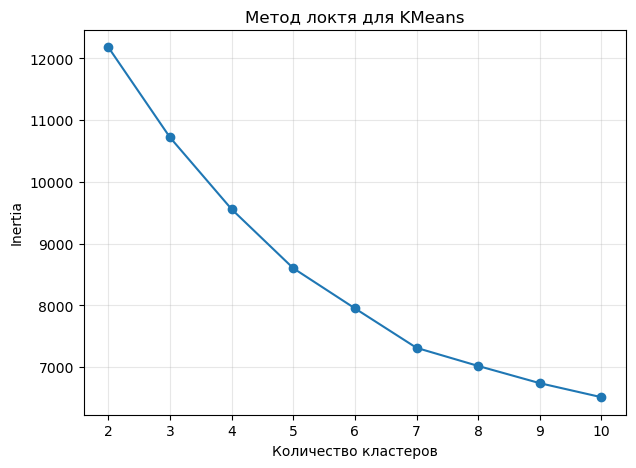

In [148]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=67,
        n_init=10
    )
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.title("Метод локтя для KMeans")
plt.grid(True, alpha=0.3)
plt.show()

По графику метода локтя видно, что инертия постепенно уменьшается при увеличении числа кластеров.
Наиболее заметное снижение происходит примерно до 5-7 кластеров, после этого кривая становится более плавной. Это означает, что добавление новых кластеров уже не так сильно улучшает разбиение.
В качестве разумного варианта можно выбрать 7 кластеров, так как после этого значения inertia уменьшаются значительно медленнее.При этом для более простой интерпретации можно оставить 3 кластера, но по данному графику локоть заметнее ближе к 7.

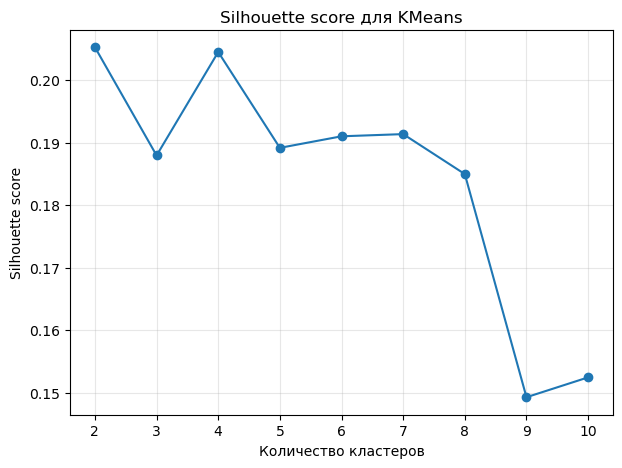

In [149]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=67,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette score")
plt.title("Silhouette score для KMeans")
plt.grid(True, alpha=0.3)
plt.show()

По графику силуэта максимальное значение получается при 2 кластерах. Также близкое значение наблюдается при 4 кластерах.
При этом сами значения silhouette score невысокие: около 0.20. Это означает, что кластеры разделяются не очень четко и частично пересекаются между собой.

Если ориентироваться только на silhouette score, лучше выбрать 2 кластера. Если учитывать еще и метод локтя, можно выбрать 4 кластера как компромиссный вариант.

In [150]:
kmeans = KMeans(
    n_clusters=4,
    random_state=67,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_cluster)
df_cluster["kmeans_cluster"] = kmeans_labels
df_cluster["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    323
1    401
2     26
3    609
Name: count, dtype: int64

Разбили на 4

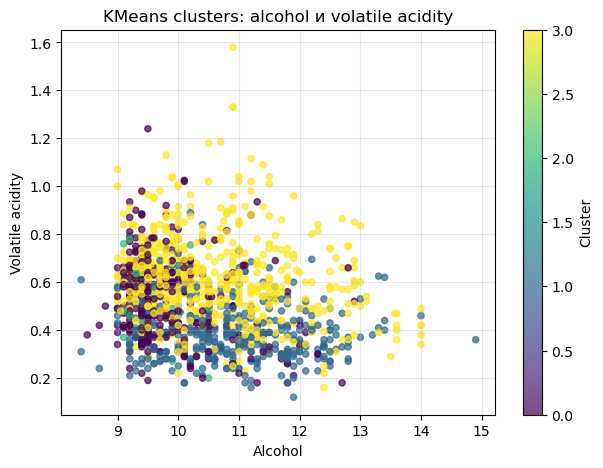

In [151]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_cluster["alcohol"],
    df_cluster["volatile acidity"],
    c=df_cluster["kmeans_cluster"],
    alpha=0.7,
    s=20
)

plt.xlabel("Alcohol")
plt.ylabel("Volatile acidity")
plt.title("KMeans clusters: alcohol и volatile acidity")
plt.colorbar(label="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

На графике показаны кластеры KMeans по двум признакам: alcohol и volatile acidity.

Кластеры частично пересекаются, поэтому четкого визуального разделения на этих двух признаках нет. Это согласуется с невысоким silhouette score.
При этом видно, что часть объектов с большим значением alcohol чаще попадает в отдельные кластеры. Также вина с высокой volatile acidity в основном расположены в верхней части графика и образуют свою область.

В целом KMeans выделил группы вин с разными сочетаниями химических характеристик, но границы между группами не являются резкими. Короче да... прикол

In [152]:
kmeans_analysis = df_cluster.groupby("kmeans_cluster").agg({
    "alcohol": ["mean", "min", "max"],
    "volatile acidity": ["mean", "min", "max"],
    "sulphates": ["mean", "min", "max"],
    "density": ["mean", "min", "max"],
    "quality": ["mean", "min", "max", "count"]
})

df_cluster.groupby("kmeans_cluster").mean(numeric_only=True).round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
kmeans_cluster,,,,,,,,,,,,
0,8.185,0.533,0.294,3.001,0.087,26.992,90.175,0.997,3.278,0.628,9.843,5.316
1,10.135,0.396,0.469,2.613,0.085,10.763,28.988,0.998,3.203,0.722,10.842,6.017
2,8.473,0.520,0.509,2.004,0.367,15.308,60.346,0.997,3.049,1.257,9.492,5.346
3,7.169,0.616,0.121,2.233,0.079,13.410,35.003,0.996,3.408,0.608,10.515,5.539


По таблице средних значений видно, что кластеры KMeans отличаются.

Кластер 1 имеет самое высокое среднее качество: quality = 6.017. Для него характерны более высокий alcohol, citric acidи относительно низкая volatile acidity

Кластеры 0 и 2 имеют более низкое среднее качество: quality. В кластере 0 заметно высокое значение total sulfur dioxide а в кластере 2 сильно выделяются chlorides и sulphates

Кластер 3 отличается самой высокой volatile acidity и самым низким значением citric acid

В целом более высокий quality связан с большим alcohol, большей citric acid и меньшей volatile acidity. Это хорошо видно на примере кластера 1.

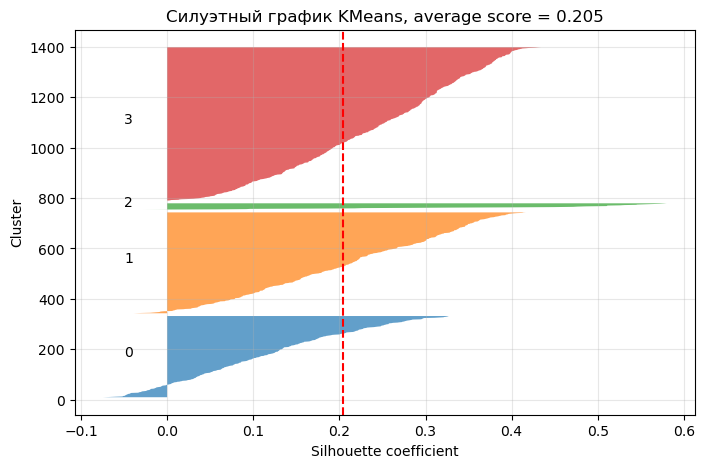

In [159]:
labels = df_cluster["kmeans_cluster"]

sample_silhouette_values = silhouette_samples(X_cluster, labels)
plt.figure(figsize=(8, 5))
y_lower = 10

for i in range(4):
    cluster_silhouette_values = sample_silhouette_values[labels == i]
    cluster_silhouette_values.sort()

    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_values,
        alpha=0.7
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

avg_score = silhouette_score(X_cluster, labels)

plt.axvline(
    x=avg_score,
    color="r",
    linestyle="--"
)

plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title(f"Силуэтный график KMeans, average score = {avg_score:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

Средний silhouette score получился невысоким. Это значит, что кластеры разделены не очень четко.

На графике видно, что часть объектов находится близко к границам кластеров.

Лучше всего отделяется один небольшой кластер, но остальные группы частично пересекаются.

В целом KMeans выделил некоторую структуру в данных, но кластеры нельзя назвать хорошо разделенными.

In [154]:
dbscan = DBSCAN(
    eps=2.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_cluster)
df_cluster["dbscan_cluster"] = dbscan_labels
df_cluster["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     111
 0    1231
 1      12
 2       5
Name: count, dtype: int64

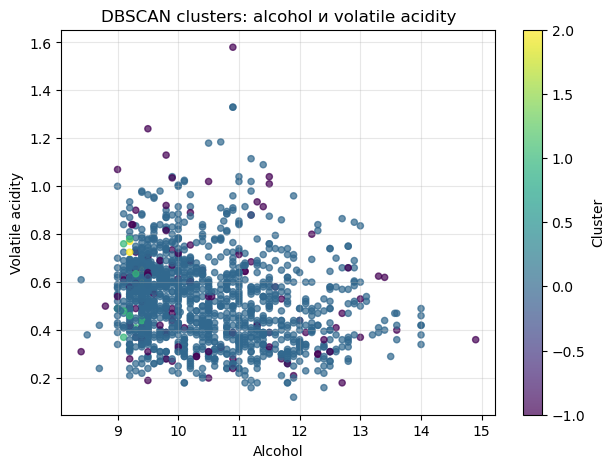

In [155]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_cluster["alcohol"],
    df_cluster["volatile acidity"],
    c=df_cluster["dbscan_cluster"],
    alpha=0.7,
    s=20
)

plt.xlabel("Alcohol")
plt.ylabel("Volatile acidity")
plt.title("DBSCAN clusters: alcohol и volatile acidity")
plt.colorbar(label="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

На графике DBSCAN видно, что основная часть объектов попала в один большой кластер.

Небольшая часть точек выделена как отдельные группы или шум. Это означает, что DBSCAN нашел плотную центральную область, но не смог хорошо разделить данные на несколько крупных кластеров.

По двум признакам alcohol и volatile acidity группы сильно пересекаются. Поэтому DBSCAN на этих данных выглядит менее удобным для интерпретации, чем KMeans.

In [156]:
dbscan_analysis = df_cluster.groupby("dbscan_cluster").agg({
    "alcohol": ["mean", "min", "max"],
    "volatile acidity": ["mean", "min", "max"],
    "sulphates": ["mean", "min", "max"],
    "density": ["mean", "min", "max"],
    "quality": ["mean", "min", "max", "count"]
})

dbscan_analysis.round(3)

alcohol            volatile acidity             sulphates  \
                  mean  min   max             mean   min   max      mean   
dbscan_cluster                                                             
-1              10.480  8.4  14.9            0.563  0.18  1.58     0.826   
 0              10.444  8.4  14.0            0.526  0.12  1.33     0.639   
 1               9.217  9.0   9.4            0.511  0.32  0.78     1.194   
 2               9.320  9.2   9.4            0.667  0.59  0.77     0.574   

                           density               quality                
                 min   max    mean    min    max    mean min max count  
dbscan_cluster                                                          
-1              0.39  2.00   0.998  0.990  1.004   5.514   3   8   111  
 0              0.33  1.20   0.997  0.991  1.001   5.639   3   8  1231  
 1              1.06  1.34   0.997  0.996  0.998   5.333   5   6    12  
 2              0.49  0.77   0.998  0.998  0.999   5.000   5   5     5

Вот как бы тут и подтверждение) 

In [157]:
dbscan_labels = df_cluster["dbscan_cluster"]

unique_labels = set(dbscan_labels)

if len(unique_labels) > 1:
    dbscan_silhouette = silhouette_score(X_cluster, dbscan_labels)
    print("Silhouette score для DBSCAN:", round(dbscan_silhouette, 3))
else:
    print("DBSCAN выделил только один кластер. Silhouette score посчитать нельзя.")

Silhouette score для DBSCAN: 0.257


In [158]:
mask = df_cluster["dbscan_cluster"] != -1

labels_without_noise = df_cluster.loc[mask, "dbscan_cluster"]
X_without_noise = X_cluster.loc[mask]

if len(set(labels_without_noise)) > 1:
    dbscan_silhouette_without_noise = silhouette_score(
        X_without_noise,
        labels_without_noise
    )
    print(
        "Silhouette score для DBSCAN без шумовых точек:",
        round(dbscan_silhouette_without_noise, 3)
    )
else:
    print("После удаления шума осталось меньше двух кластеров.")

Silhouette score для DBSCAN без шумовых точек: 0.309


Silhouette score для DBSCAN получился выше, чем у KMeans. Если убрать шумовые точки, качество разбиения становится еще немного лучше.

Это означает, что DBSCAN смог выделить более плотные группы объектов. Однако основная часть данных все равно попала в один большой кластер, а остальные кластеры получились маленькими.

Поэтому DBSCAN формально показывает лучшее значение silhouette score, но с точки зрения интерпретации он менее удобен: он скорее выделяет шум и небольшие группы, чем делит все вина на понятные крупные кластеры.

Ну в сумме домашка прикольная, жаль датасет я выбрал не интересный и бесполезный, но просто покопаться в смыслах и идеях было прикольно) 